Загрузка датасета. 
Вывод первых 5 строк, последних 5 строк, информации о датасете, средние значения, проверка пропусков.


In [24]:
import pandas as pd 

df = pd.DataFrame((pd.read_csv('supermarket_sales.csv')))
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())
print(df.isnull().sum())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1415     9.1  
1  10:

Какой филиал (Branch) приносит больше всего выручки?

In [25]:
branch_totals = df.groupby('Branch')['Total'].sum()
max_branch = branch_totals.idxmax()
max_total = branch_totals.max()
print(f"Максимальная выручка у филиала {max_branch}. Сумма: {max_total:,.2f}")

Максимальная выручка у филиала C. Сумма: 110,568.71


Какая категория товаров (Product line) самая популярная по количеству транзакций? 

In [26]:
counts = df['Product line'].value_counts()
pop_prod = counts.idxmax()
print(f"Самая популярная категория товаров: {pop_prod}")

Самая популярная категория товаров: Fashion accessories


Какой средний чек (Total) у Member и Normal (Customer type) клиентов? Есть ли разница? 

In [27]:
cus_total_mean = df.groupby('Customer type')['Total'].mean()
tot_mem = float(cus_total_mean['Member'])
tot_nor = float(cus_total_mean['Normal'])
print(f"Средний чек у Member равен {tot_mem:,.2f}")
print(f"Средний чек у Normal равен {tot_nor:,.2f}")
max_cus_tot = cus_total_mean.idxmax()
max_tot = cus_total_mean.max()
min_tot = cus_total_mean.min()
dif = max_tot - min_tot
print(f"Средний чек больше у {max_cus_tot} на {dif:,.2f}")

Средний чек у Member равен 327.79
Средний чек у Normal равен 318.12
Средний чек больше у Member на 9.67


Создать pivot_table: средний Rating по Branch и Gender

In [28]:
pivot_rating = df.pivot_table(values='Rating', index='Branch', columns='Gender', aggfunc='mean').round(2)
print(pivot_rating)

Gender  Female  Male
Branch              
A         6.84  7.20
B         6.88  6.76
C         7.16  6.97


Создать pivot_table: суммарная выручка (Total) по Product line и Customer type

In [29]:
pivot_total = df.pivot_table(values='Total', index='Product line', columns='Customer type', aggfunc='sum')
print(pivot_total)

Customer type               Member      Normal
Product line                                  
Electronic accessories  24498.4950  29839.0365
Fashion accessories     26323.9620  27981.9330
Food and beverages      31357.6200  24787.2240
Health and beauty       25831.0395  23362.6995
Home and lifestyle      27978.0270  25883.8860
Sports and travel       28234.3005  26888.5260


Преобразовать Date в datetime 

In [30]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
print(df.head())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715 2019-01-05   
1  Electronic accessories       15.28         5   3.8200   80.2200 2019-03-08   
2      Home and lifestyle       46.33         7  16.2155  340.5255 2019-03-03   
3       Health and beauty       58.22         8  23.2880  489.0480 2019-01-27   
4       Sports and travel       86.31         7  30.2085  634.3785 2019-02-08   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1415     9.1  
1  10:

Создать новые колонки: Month, DayOfWeek, Hour (из Time)

In [31]:
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour
print(df[['Date', 'Time', 'Month', 'DayOfWeek', 'Hour']].head())

        Date   Time  Month DayOfWeek  Hour
0 2019-01-05  13:08      1  Saturday    13
1 2019-03-08  10:29      3    Friday    10
2 2019-03-03  13:23      3    Sunday    13
3 2019-01-27  20:33      1    Sunday    20
4 2019-02-08  10:37      2    Friday    10


Какой день недели самый прибыльный по суммарной выручке? 

In [32]:
total_day = df.groupby('DayOfWeek')['Total'].sum()
max_day = total_day.idxmax()
max_total = total_day.max()
print(f"Максимальная выручка в {max_day}. Сумма: {max_total}")

Максимальная выручка в Saturday. Сумма: 56120.8095


Создать колонку Rating_category:High, если Rating>=8, иначе Low

In [33]:
df['Rating_category']=df['Rating'].apply(lambda x: 'High' if x >= 8 else 'Low')
print(df[['Rating', 'Rating_category']])

     Rating Rating_category
0       9.1            High
1       9.6            High
2       7.4             Low
3       8.4            High
4       5.3             Low
..      ...             ...
995     6.2             Low
996     4.4             Low
997     7.7             Low
998     4.1             Low
999     6.6             Low

[1000 rows x 2 columns]


Создать колонку Revenue_per_item = Total / Quantity

In [34]:
df['Revenue_per_item'] = df['Total'] / df['Quantity']
print(df[['Total', 'Quantity', 'Revenue_per_item']])

         Total  Quantity  Revenue_per_item
0     548.9715         7           78.4245
1      80.2200         5           16.0440
2     340.5255         7           48.6465
3     489.0480         8           61.1310
4     634.3785         7           90.6255
..         ...       ...               ...
995    42.3675         1           42.3675
996  1022.4900        10          102.2490
997    33.4320         1           33.4320
998    69.1110         1           69.1110
999   649.2990         7           92.7570

[1000 rows x 3 columns]


Посчитать распределение Rating_category (в процентах)

In [36]:
percent = df['Rating_category'].value_counts(normalize = True )*100
print(percent)

Rating_category
Low     67.1
High    32.9
Name: proportion, dtype: float64


Построить гистограмму распределения  Total (20 бинов, подписать оси)

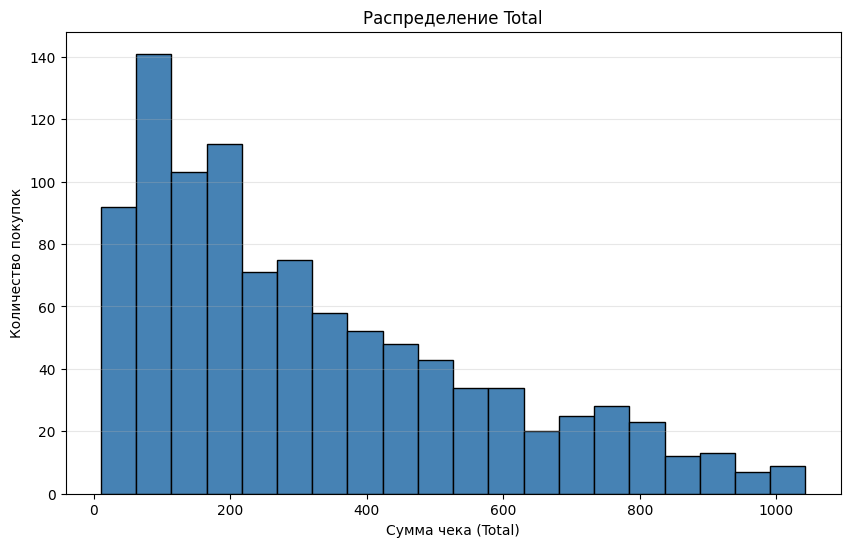

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Total'], bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Сумма чека (Total)')
plt.ylabel('Количество покупок')
plt.title('Распределение Total')
plt.grid(axis='y', alpha=0.3)
plt.show()

Boxplot Rating по Branch (разброс оценок по филиалам)

<Figure size 1000x600 with 0 Axes>

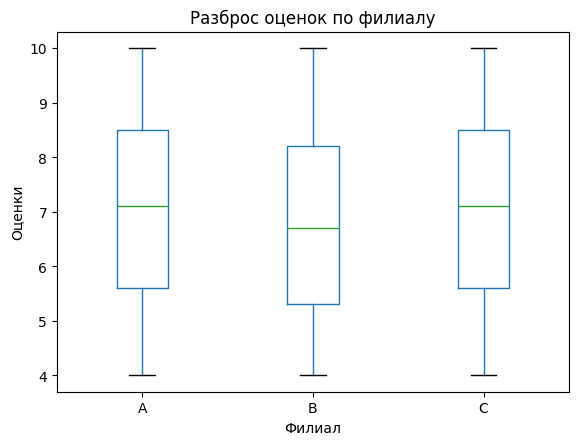

In [43]:
plt.figure(figsize=(10, 6))
df.boxplot(column='Rating', by='Branch', grid=False)
plt.xlabel('Филиал')
plt.ylabel('Оценки')
plt.title('Разброс оценок по филиалу')
plt.suptitle('')  
plt.show()

Barplot топ-5 категорий Product line по суммарной выручке (горизонтальный или вертикальный - на свой вкус, подписать значения)

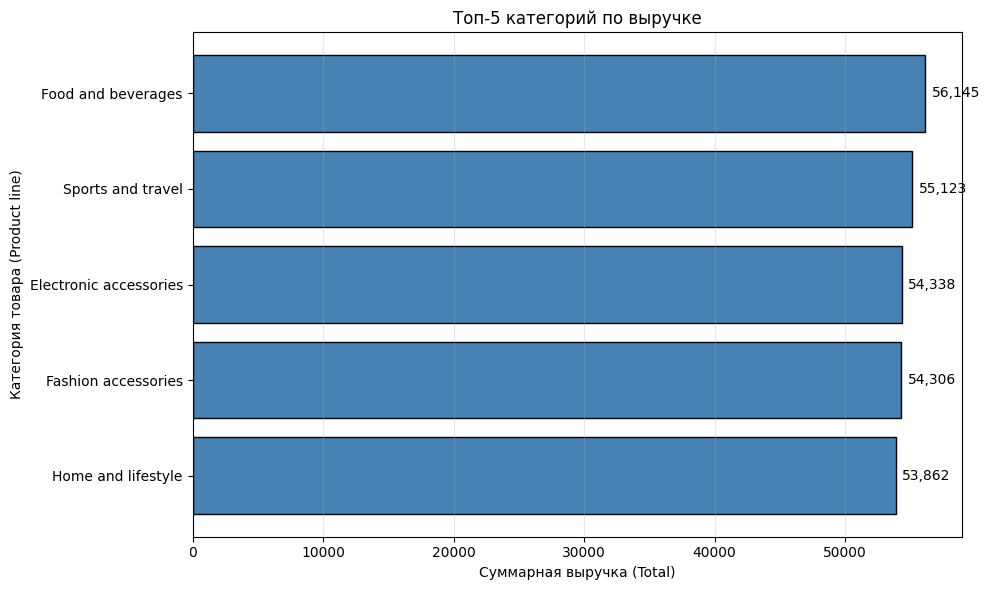

In [44]:
top5 = df.groupby('Product line')['Total'].sum().sort_values(ascending=True).tail(5)
plt.figure(figsize=(10, 6))
bars = plt.barh(top5.index, top5.values, color='steelblue', edgecolor='black')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}', va='center', fontsize=10)
plt.xlabel('Суммарная выручка (Total)')
plt.ylabel('Категория товара (Product line)')
plt.title('Топ-5 категорий по выручке')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()